In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import scanpy as sc
import matplotlib.pyplot as plt 
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import processing, utils, plotting
import imputations 
import pandas as pd
from scipy.stats import spearmanr, pearsonr


print(sc.__version__)

In [ ]:
allmeshes = utils.load_mesh()

mesh = allmeshes['250513_LC_core_67_mesh_shrunk']
mesh.vertices = mesh.vertices/25

In [ ]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
# adata_mer.obsm['spatial'] *=25
adata_mer = adata_mer[adata_mer.obs['leiden']!='5',:]
adata_mer.shape
sc.pp.normalize_total(adata_mer, 1e4)

# run umap 
umap_random_state = 307
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)


# 1. find  genes correlated with CCA1

In [41]:

scaler_X = StandardScaler().fit(adata_mer.X)
X_mer_scaled = scaler_X.transform(adata_mer.X)

S_mer = processing.get_hemi(adata_mer.obsm['spatial'])    
scaler_S = StandardScaler().fit(S_mer)
S_mer_scaled = scaler_S.transform(S_mer)
# S_mer_scaled = S_mer.copy()


In [42]:
S_mer[:,2].max(), S_mer[:,2].min()

(214.4532201289624, 139.2048056994244)

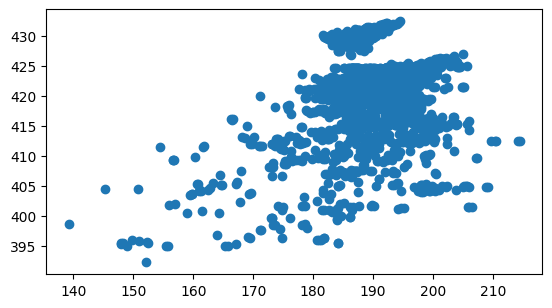

In [43]:
plt.scatter(S_mer[:,2],S_mer[:,0])
plt.gca().set_aspect('equal')

In [58]:
np.ptp(S_mer_scaled,0)

array([5.71929256, 8.53873831, 9.61212726])

In [59]:
np.std(S_mer_scaled,0)

array([1., 1., 1.])

In [44]:
n_components = 2
cca = CCA(n_components=n_components)
cca.fit(X_mer_scaled, S_mer_scaled)
X_c, S_c = cca.transform(X_mer_scaled, S_mer_scaled)
canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
print("Canonical correlations:", canonical_correlations)

Canonical correlations: [0.9292427774025579, 0.8018907154795526]


In [45]:
cca.y_weights_

array([[-0.9963945 , -0.05430738],
       [-0.06679366,  0.97584831],
       [-0.05231269, -0.21159109]])

### A. CCA1

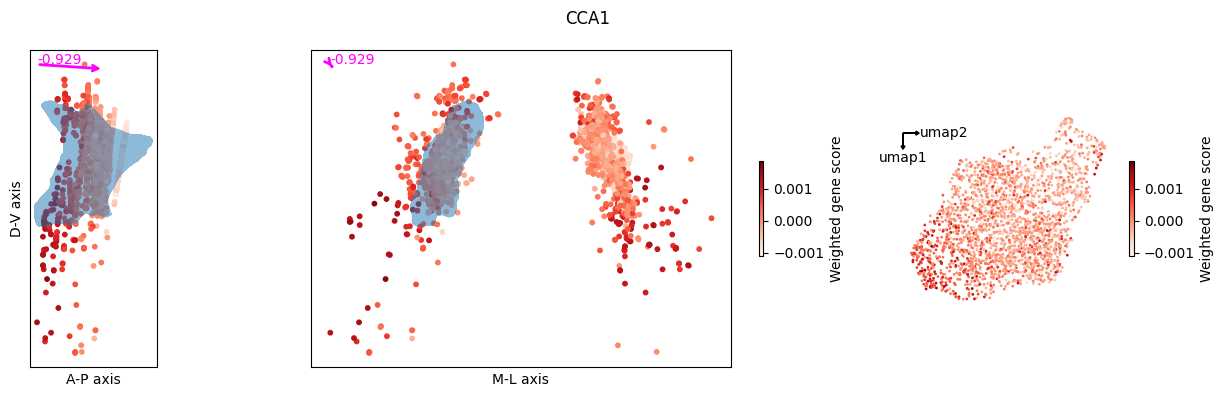

In [53]:
k = 0
scale_factor = 30 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(13,4),
    gridspec_kw={'width_ratios': [1, 2, 1]})

ax1.scatter(adata_mer.obsm['spatial'][:, 0], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
ax1.set_aspect('equal')

start_point_all = np.min(adata_mer.obsm['spatial'],0)
start_point = (start_point_all[0],start_point_all[1])
end_point = (start_point_all[0] + vector_scaled[0], start_point_all[1] + vector_scaled[1])
ax1.annotate('',xy=end_point,xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax1.text(start_point[0],start_point[1],np.around(-canonical_correlations[k],3).astype(str), color = 'magenta')

ax1.triplot(mesh.vertices.T[0], mesh.vertices.T[1], mesh.faces, alpha = .5, label = '67%')
ax1.invert_yaxis()
ax1.grid(False)
ax1.set_yticks([])
ax1.set_ylabel("D-V axis")
ax1.set_xticks([])
ax1.set_xlabel("A-P axis")


sca = ax2.scatter(
    adata_mer.obsm['spatial'][:, 2],adata_mer.obsm['spatial'][:, 1],
    c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, ax=ax2, label='Weighted gene score', shrink=0.3)
ax2.set_aspect('equal')
start_point_all = np.min(adata_mer.obsm['spatial'],0)
start_point = (start_point_all[2],start_point_all[1])
end_point = (start_point_all[2] + vector_scaled[2], start_point_all[1] + vector_scaled[1])

ax2.triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha = .5, label = '67%')
ax2.annotate('',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax2.text(start_point[0],start_point[1],np.around(-canonical_correlations[k],3).astype(str), color = 'magenta')
ax2.invert_yaxis()
ax2.grid(False)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_xlabel("M-L axis")


s = 1
fs = 10
sca = ax3.scatter(adata_mer.obsm['X_umap'][:, 1], adata_mer.obsm['X_umap'][:, 0], c=X_c[:, k],cmap='Reds',s=s)
ax3.set_aspect('equal')    
cbar = plt.colorbar(sca, ax=ax3, label='Weighted gene score', shrink=0.3)

for spine in ax3.spines.values():
    spine.set_visible(False)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.invert_yaxis()

y0,x0 = np.min(adata_mer.obsm['X_umap'], 0)
y0*=1.4
x0*=0.8
ax3.arrow(x0, y0, 1, 0,
         head_width=0.25, head_length=0.2,
         length_includes_head=True, linewidth=1, color='k')
ax3.arrow(x0, y0, 0, 1,
         head_width=0.25, head_length=0.2,
         length_includes_head=True, linewidth=1, color='black')

ax3.text(x0+1.05, y0, 'umap2', va='center', ha='left', fontsize=fs)
ax3.text(x0, y0+2, 'umap1', va='bottom', ha='center', fontsize=fs)
ax3.set_aspect('equal')
fig.suptitle(f'CCA{k+1}')
fig.tight_layout()

plt.show()

### B. CCA2

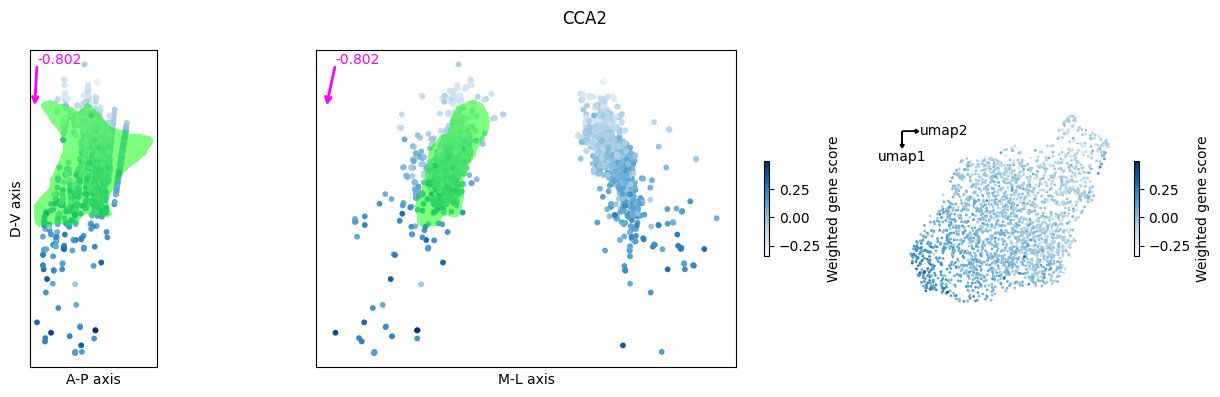

In [55]:
k = 1
scale_factor =-20 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(13,4),
    gridspec_kw={'width_ratios': [1, 2, 1]})

ax1.scatter(adata_mer.obsm['spatial'][:, 0], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
ax1.set_aspect('equal')

start_point_all = np.min(adata_mer.obsm['spatial'],0)
start_point = (start_point_all[0],start_point_all[1])
end_point = (start_point_all[0] + vector_scaled[0], start_point_all[1] + vector_scaled[1])
ax1.annotate('',xy=end_point,xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax1.text(start_point[0],start_point[1],np.around(-canonical_correlations[k],3).astype(str), color = 'magenta')

ax1.triplot(mesh.vertices.T[0], mesh.vertices.T[1], mesh.faces, alpha = .5, label = '67%', color = 'lime')
ax1.invert_yaxis()
ax1.grid(False)
ax1.set_yticks([])
ax1.set_ylabel("D-V axis")
ax1.set_xticks([])
ax1.set_xlabel("A-P axis")


sca = ax2.scatter(
    adata_mer.obsm['spatial'][:, 2],adata_mer.obsm['spatial'][:, 1],
    c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, ax=ax2, label='Weighted gene score', shrink=0.3)
ax2.set_aspect('equal')
start_point_all = np.min(adata_mer.obsm['spatial'],0)
start_point = (start_point_all[2],start_point_all[1])
end_point = (start_point_all[2] + vector_scaled[2], start_point_all[1] + vector_scaled[1])

ax2.triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha = .5, label = '67%',color = 'lime')
ax2.annotate('',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax2.text(start_point[0],start_point[1],np.around(-canonical_correlations[k],3).astype(str), color = 'magenta')
ax2.invert_yaxis()
ax2.grid(False)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_xlabel("M-L axis")


s = 1
fs = 10
sca = ax3.scatter(adata_mer.obsm['X_umap'][:, 1], adata_mer.obsm['X_umap'][:, 0], c=X_c[:, k],cmap='Blues',s=s)
ax3.set_aspect('equal')    
cbar = plt.colorbar(sca, ax=ax3, label='Weighted gene score', shrink=0.3)

for spine in ax3.spines.values():
    spine.set_visible(False)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.invert_yaxis()

y0,x0 = np.min(adata_mer.obsm['X_umap'], 0)
y0*=1.4
x0*=0.8
ax3.arrow(x0, y0, 1, 0,
         head_width=0.25, head_length=0.2,
         length_includes_head=True, linewidth=1, color='k')
ax3.arrow(x0, y0, 0, 1,
         head_width=0.25, head_length=0.2,
         length_includes_head=True, linewidth=1, color='black')

ax3.text(x0+1.05, y0, 'umap2', va='center', ha='left', fontsize=fs)
ax3.text(x0, y0+2, 'umap1', va='bottom', ha='center', fontsize=fs)
ax3.set_aspect('equal')
fig.suptitle(f'CCA{k+1}')
fig.tight_layout()
plt.show()

##  find the genes that are highly correlated

        gene  spearman_corr       p_value
304    Grik1      -0.390499  6.255006e-83
191     Pax5       0.389933  1.125745e-82
292     Vwc2      -0.382278  2.846295e-79
63     Cpne4      -0.363074  3.973143e-71
70     Crim1      -0.360861  3.179142e-70
275  Tmem178      -0.342547  5.106453e-63
161     Nefh      -0.342181  7.035419e-63
251   Slc6a2       0.342143  7.270814e-63
60    Col6a5       0.341549  1.222411e-62
237    Shox2      -0.334156  7.108416e-60


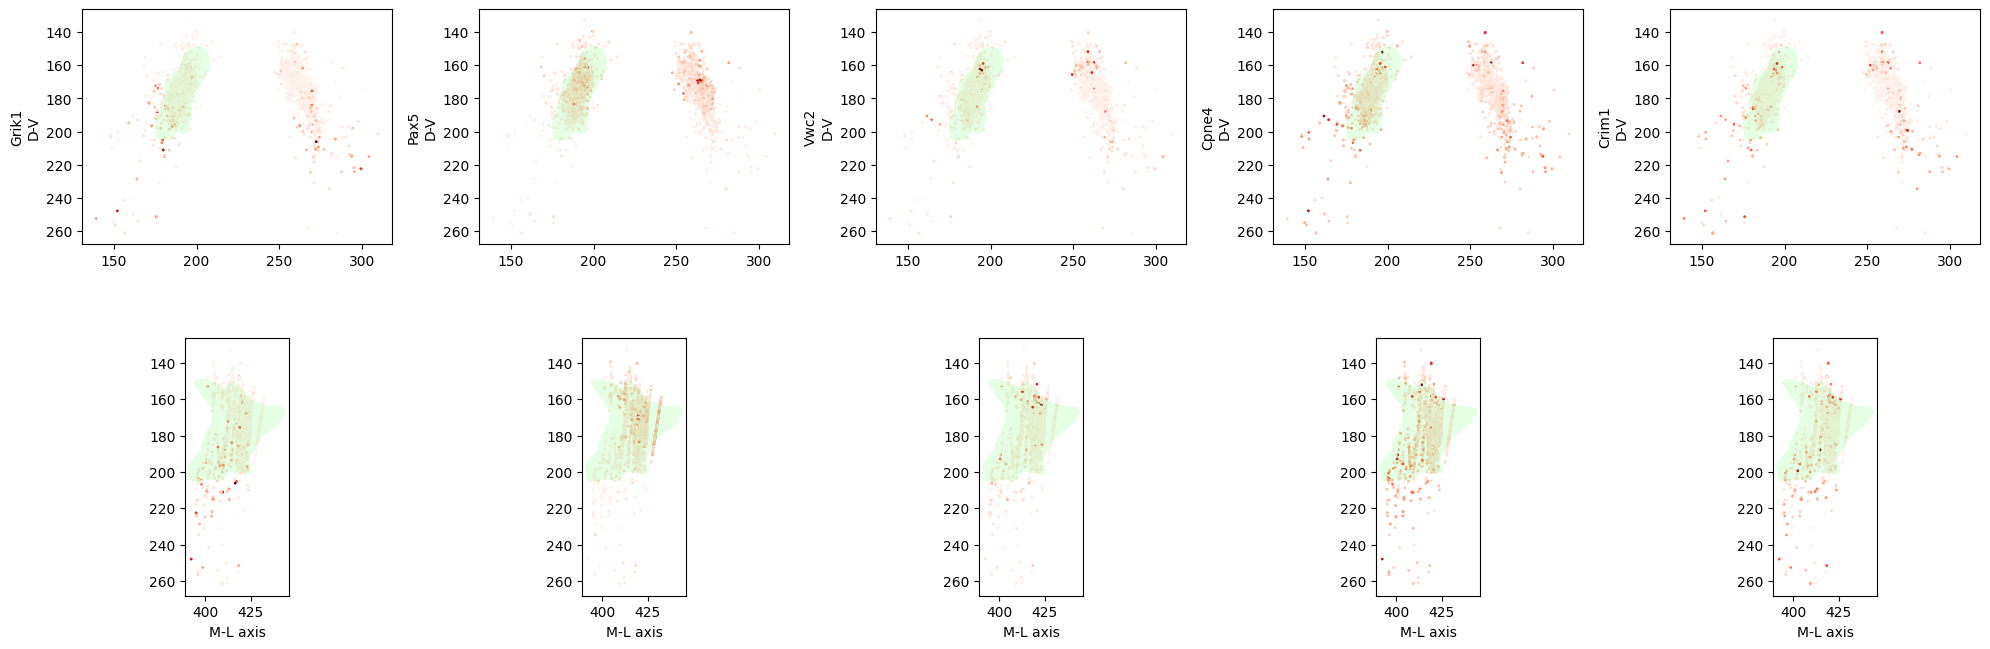

In [56]:
import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")

k=0
chosencolor = 'Reds' if k==0 else 'Blues'
direction_of_interest = -(cca.y_weights_[:,k]) 
S_mer = processing.get_hemi(adata_mer.obsm['spatial'], mesh_LC)    
direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
projected = S_mer @ direction_norm
if hasattr(adata_mer.X, 'toarray'):
    X = adata_mer.X.toarray()
else:
    X = np.array(adata_mer.X)
gene_names = adata_mer.var_names
results = []
for i, gene in enumerate(gene_names):
    expr = X[:, i]
    corr, pval = spearmanr(expr, projected)
    results.append((gene, corr, pval))

df_results = pd.DataFrame(results, columns=['gene', 'spearman_corr', 'p_value'])
df_results_sorted = df_results.sort_values(by='spearman_corr', key=lambda s: s.abs(), ascending=False)

newly_found = list(df_results_sorted['gene'])
print(df_results_sorted.head(10))


T = 5
fig, axes = plt.subplots(2,T,figsize = (4*T,8),gridspec_kw={'height_ratios': [2,1]})
for t in range(T):
    a = axes[0,t]
    a.scatter(adata_mer.obsm['spatial'][:, 2],adata_mer.obsm['spatial'][:, 1],
                c=adata_mer[:,newly_found[t]].X.toarray(),cmap=chosencolor,s=1)
    a.triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha = .1, label = '67%', color = 'lime')
    a.invert_yaxis()
    a.set_aspect('equal')
    a.set_ylabel(f'{newly_found[t]}\nD-V')
#     a.set_xlabel('M-L axis') if a == axes[-1] else a.set_xlabel('')
    
    a = axes[1,t]
    a.scatter(adata_mer.obsm['spatial'][:, 0],adata_mer.obsm['spatial'][:, 1],
                c=adata_mer[:,newly_found[t]].X.toarray(),cmap=chosencolor,s=1)
    a.triplot(mesh.vertices.T[0], mesh.vertices.T[1], mesh.faces, alpha = .1, label = '67%', color = 'lime')
    a.invert_yaxis()
    a.set_aspect('equal')
    a.set_xlabel('M-L axis')
        
plt.tight_layout()

In [57]:
print(df_results_sorted.head(20))

        gene  spearman_corr       p_value
304    Grik1      -0.390499  6.255006e-83
191     Pax5       0.389933  1.125745e-82
292     Vwc2      -0.382278  2.846295e-79
63     Cpne4      -0.363074  3.973143e-71
70     Crim1      -0.360861  3.179142e-70
275  Tmem178      -0.342547  5.106453e-63
161     Nefh      -0.342181  7.035419e-63
251   Slc6a2       0.342143  7.270814e-63
60    Col6a5       0.341549  1.222411e-62
237    Shox2      -0.334156  7.108416e-60
77    Dnah12      -0.329657  3.143463e-58
163     Nefm      -0.321883  1.889698e-55
44     Chodl       0.320748  4.735328e-55
102    Galr2      -0.320112  7.909589e-55
97    Gabrg1      -0.316192  1.816555e-53
219     Rgs5      -0.310028  2.284450e-51
65     Cpne8      -0.306508  3.428448e-50
126     Htr7      -0.304673  1.387004e-49
101    Galr1      -0.302675  6.284273e-49
91     Fbxl7       0.297890  2.228885e-47


# 2. find sudden change genes 
(potentially fit a logistic curve, or some polynomial) 

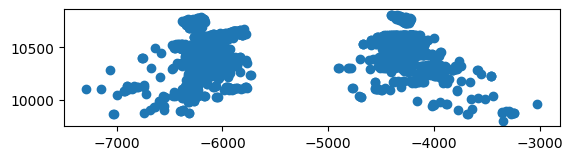

In [22]:
plt.scatter(S_mer[:,2],S_mer[:,0])
plt.gca().set_aspect('equal')

In [19]:
np.ptp(S_mer,0)

array([1004.64582191, 3228.26072217, 4264.35083532])

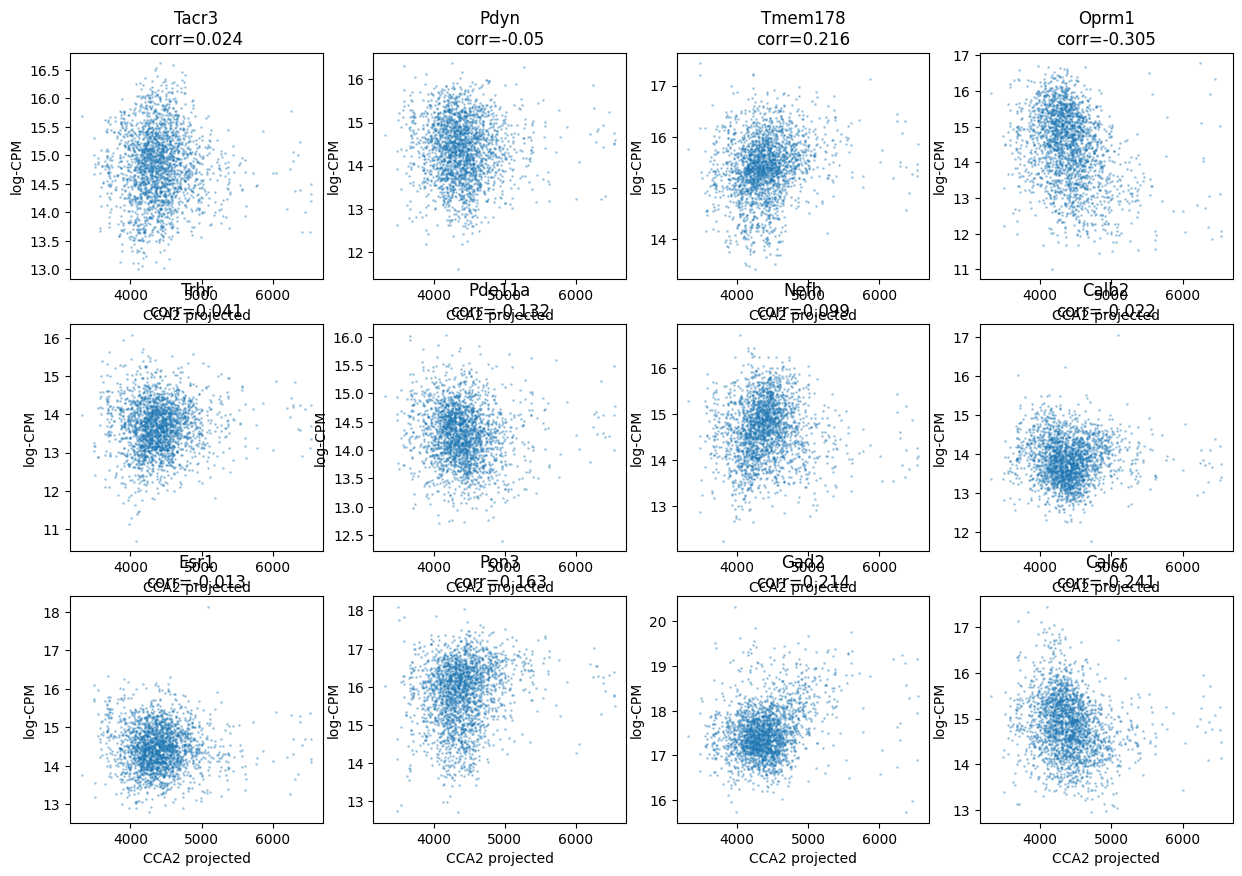

In [16]:
k=1
# direction_of_interest = (-cca.y_weights_[:,k]) 
direction_of_interest = np.array((0,1,0))
direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
projected = S_mer @ direction_norm


gene_names = adata_mer.var_names
results = []
for i, gene in enumerate(gene_names):
    expr = X[:, i]
    corr, pval = spearmanr(np.log1p(expr), projected)
    results.append((gene, corr, pval))
df_results = pd.DataFrame(results, columns=['gene', 'spearman_corr', 'p_value'])
df_results_sorted = df_results.sort_values(by='spearman_corr', key=lambda s: s.abs(), ascending=False)
newly_found = list(df_results_sorted['gene'])

plt.figure(figsize = (15,10))
for i, gene in enumerate(newly_found[:12]):
    expr = X[:, i]*1e+6
    plt.subplot(3,4,i+1)
    plt.scatter(projected, np.log1p(expr),s=1, alpha =.3)
    plt.xlabel('CCA2 projected')
    plt.ylabel('log-CPM')
    thiscorr = np.around(df_results_sorted['spearman_corr'][i],3)
    plt.title(gene+f'\ncorr={thiscorr}')
